# Lab - EDA Univariate Analysis: Diving into Amazon UK Product Insights

### **1. Download the dataset**
Kaggle requires authentication, so we must download the dataset manually:

**[https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)**

Download the file, unzip it, and place it in your working directory.

Let’s assume the main file is named:

```python

amazon_uk_products.csv
```

### **2. Load the dataset**

In [163]:
import pandas as pd

df = pd.read_csv("../amz_uk_price_prediction_dataset.csv/amz_uk_price_prediction_dataset.csv")
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [40]:
%matplotlib inline
pd.set_option('display.max_columns', None)

### **3. Basic inspection**

In [4]:
# number of rows and columns
df.shape

(2443651, 9)

In [9]:
# variable types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB


In [12]:
# missing values
df.describe(include="all")

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
count,2.443651e+06,2443651,2443651,2.443651e+06,2.443651e+06,2.443651e+06,2443651,2.443651e+06,2443651
unique,NaN,2222742,2077591,NaN,NaN,NaN,2,NaN,296
top,NaN,B0884G1PZ5,OYhmc Portable Pedal Exerc,NaN,NaN,NaN,False,NaN,Sports & Outdoors
freq,NaN,7,723,NaN,NaN,NaN,2435671,NaN,836265
mean,1.370545e+06,NaN,NaN,2.152836e+00,4.806278e+02,8.924381e+01,NaN,2.589699e+01,NaN
std,8.160562e+05,NaN,NaN,2.194865e+00,5.944124e+03,3.456089e+02,NaN,2.404837e+02,NaN
min,1.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00,NaN
25%,6.589215e+05,NaN,NaN,0.000000e+00,0.000000e+00,9.990000e+00,NaN,0.000000e+00,NaN
50%,1.349029e+06,NaN,NaN,0.000000e+00,0.000000e+00,1.909000e+01,NaN,0.000000e+00,NaN
75%,2.060686e+06,NaN,NaN,4.400000e+00,5.900000e+01,4.599000e+01,NaN,0.000000e+00,NaN


In [42]:
df.isna().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [16]:
# basic statistics
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='str')

### **4. Identify numerical vs categorical variables**

In [20]:
num = df.select_dtypes(include=['int64', 'float64'])
cat = df.select_dtypes(include=['object'])

C:\Users\user\AppData\Local\Temp\ipykernel_11548\1819320204.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = df.select_dtypes(include=['object'])


In [22]:
cat

,asin,title,category
0,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",Hi-Fi Speakers
1,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",Hi-Fi Speakers
2,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",Hi-Fi Speakers
3,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",Hi-Fi Speakers
4,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,Hi-Fi Speakers
...,...,...,...
2443646,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",Motorbike Clothing
2443647,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,Motorbike Clothing
2443648,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,Motorbike Clothing
2443649,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,Motorbike Clothing


In [23]:
num

,uid,stars,reviews,price,boughtInLastMonth
0,1,4.7,15308,21.99,0
1,2,4.7,98099,23.99,0
2,3,4.7,15308,21.99,0
3,4,4.7,7205,31.99,0
4,5,4.6,1881,17.99,0
...,...,...,...,...,...
2443646,2828589,0.0,0,22.34,0
2443647,2828590,0.0,0,97.99,0
2443648,2828591,0.0,0,52.99,0
2443649,2828592,4.3,404,79.99,0


### **5. Univariate EDA — Numerical Variables**

Let’s take **Price**, **Rating**, **Number of Reviews**, etc.

#### **A. Summary statistics**

In [26]:
round(num.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
uid,2443651.0,1370545.35,816056.17,1.0,658921.50,1349029.00,2060685.50,2828593.0
stars,2443651.0,2.15,2.19,0.0,0.00,0.00,4.40,5.0
reviews,2443651.0,480.63,5944.12,0.0,0.00,0.00,59.00,1356658.0
price,2443651.0,89.24,345.61,0.0,9.99,19.09,45.99,100000.0
boughtInLastMonth,2443651.0,25.90,240.48,0.0,0.00,0.00,0.00,50000.0


#### **B. Histograms**

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

In [81]:
df["category"].unique()

<StringArray>
[                 'Hi-Fi Speakers',         'CD, Disc & Tape Players',
             'Wearable Technology',                     'Light Bulbs',
               'Bathroom Lighting',  'Heating, Cooling & Air Quality',
      'Coffee & Espresso Machines',       'Lab & Scientific Products',
                  'Smart Speakers',              'Motorbike Clothing',
 ...
                 'Digital Cameras',                  'Digital Frames',
                  'Action Cameras',                    'Film Cameras',
 'Binoculars, Telescopes & Optics',         'Media Streaming Devices',
     'Hi-Fi Receivers & Separates',      'GPS, Finders & Accessories',
                 'Indoor Lighting',                   'String Lights']
Length: 296, dtype: str

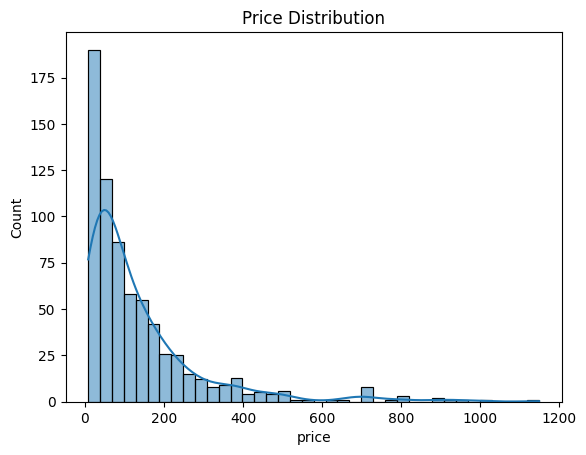

In [100]:
sns.histplot(df["price"].head(700), bins="auto", kde=True)
plt.title("Price Distribution")
plt.show()

#### **C. Outlier detection**

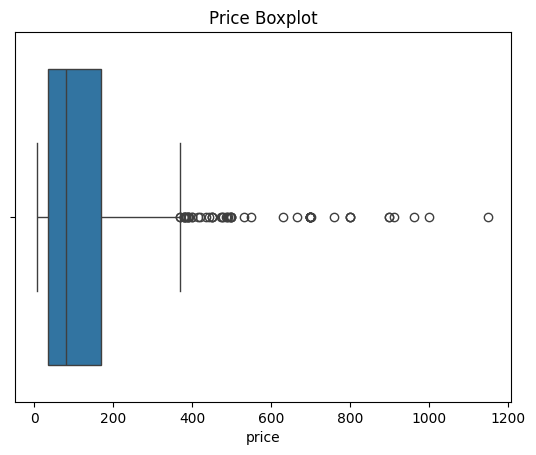

In [99]:
sns.boxplot(x=df['price'].head(700))
plt.title("Price Boxplot")
plt.show()

### **6. Univariate EDA — Categorical Variables**

Let’s take **Category**, **Brand**, **Subcategory**, etc.

#### **A. Frequency table**

In [34]:
df['category'].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

#### **B. Proportion table**

In [37]:
df['category'].value_counts(normalize=True).round(4)

category
Sports & Outdoors                         0.3422
Beauty                                    0.0079
Handmade Clothing, Shoes & Accessories    0.0079
Bath & Body                               0.0078
Birthday Gifts                            0.0078
                                           ...  
Motorbike Chassis                         0.0000
Alexa Built-In Devices                    0.0000
Plugs                                     0.0000
Smart Home Security & Lighting            0.0000
Smart Speakers                            0.0000
Name: proportion, Length: 296, dtype: float64

#### **C. Bar plot**

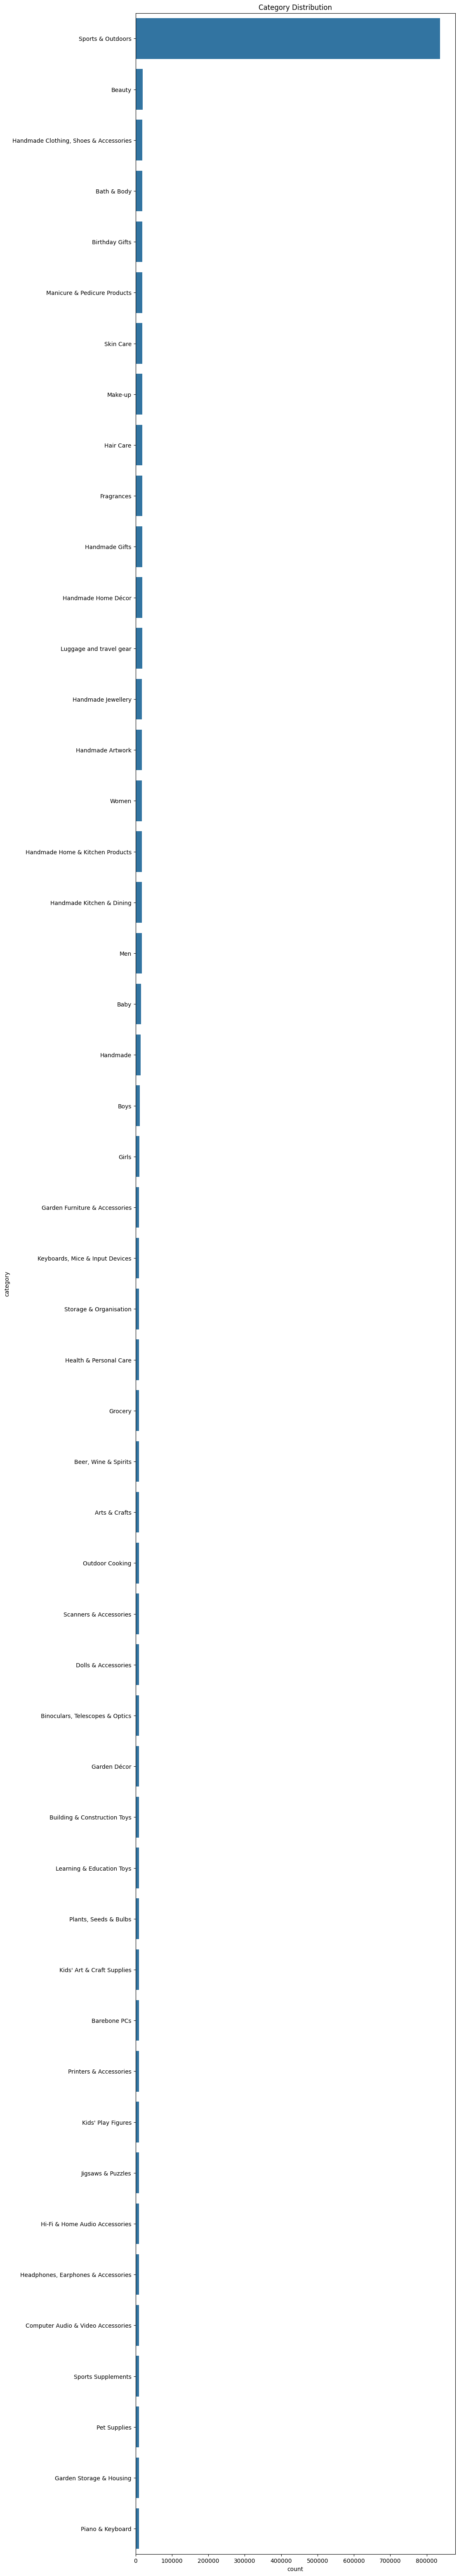

In [111]:
plt.figure(figsize=(10,80))
sns.countplot(y=df['category'], order=df['category'].value_counts().head(50).index)
plt.title("Category Distribution")
plt.show()

### **7. Missing values**

In [110]:
missing = df.isna().sum()
missing[missing > 0]

Series([], dtype: int64)

### **8. Duplicates**

In [49]:
df.duplicated().sum()

np.int64(0)

## **Part 1: Understanding Product Categories**

### **1. Frequency Tables**

#### **A. Frequency table for product categories**

This shows how many products belong to each category.

In [112]:
frequency_table = df['category'].value_counts()
frequency_table

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

#### **B. Top 5 most listed categories**

This answers the business question:

* Which product categories dominate Amazon UK listings?

In [53]:
top5_categories = df['category'].value_counts().head(5)
top5_categories

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

### **2. Visualizations**

#### **A. Bar chart — Distribution of all categories**
If the dataset has many categories, the chart may be crowded. Still, here is the full version:

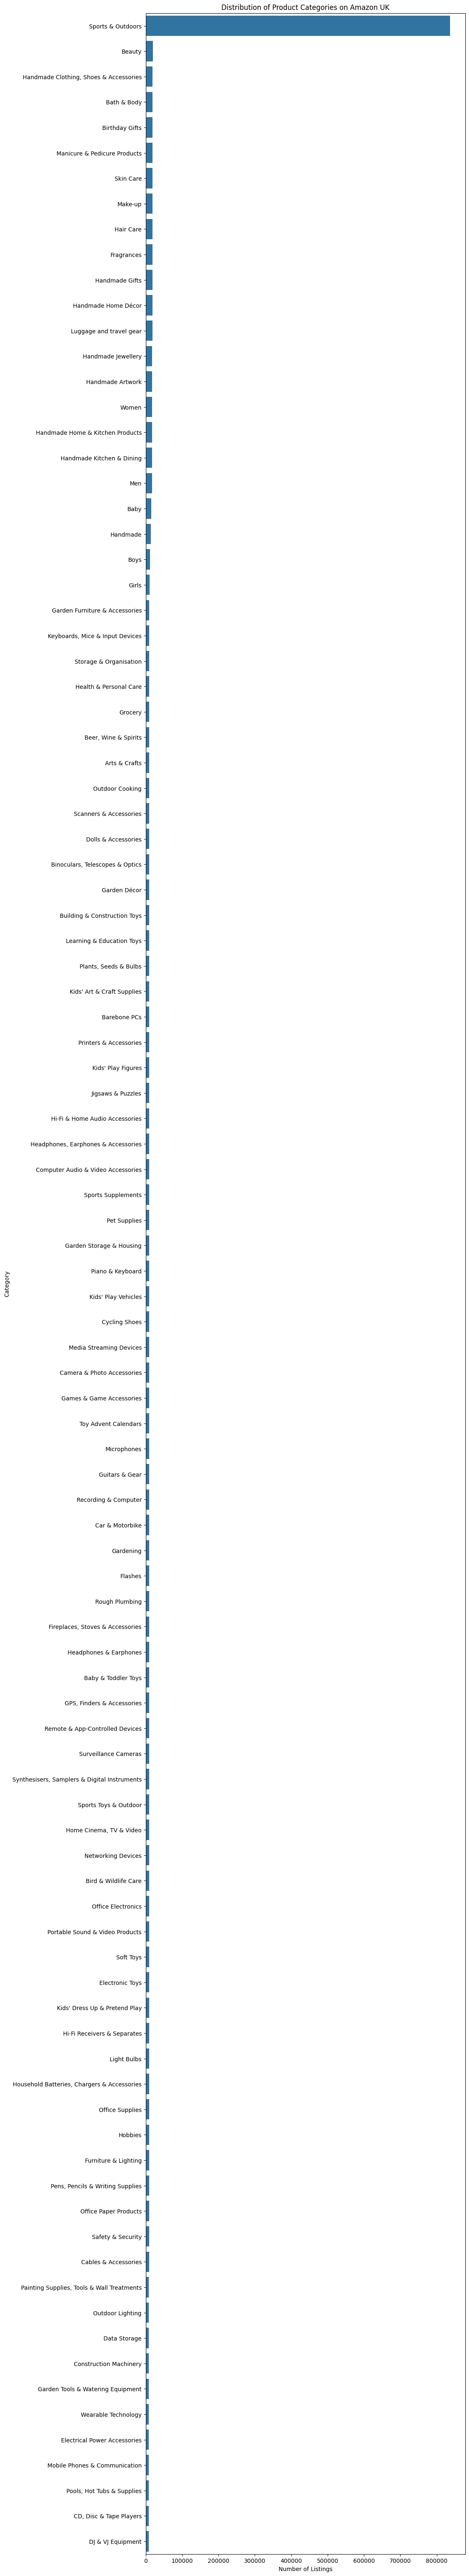

In [80]:
plt.figure(figsize=(10,80))
sns.countplot(y=df['category'], order=df['category'].value_counts().head(100).index)
plt.title("Distribution of Product Categories on Amazon UK")
plt.xlabel("Number of Listings")
plt.ylabel("Category")
plt.show()


### **B. Bar chart — Top 5 categories only (cleaner)**

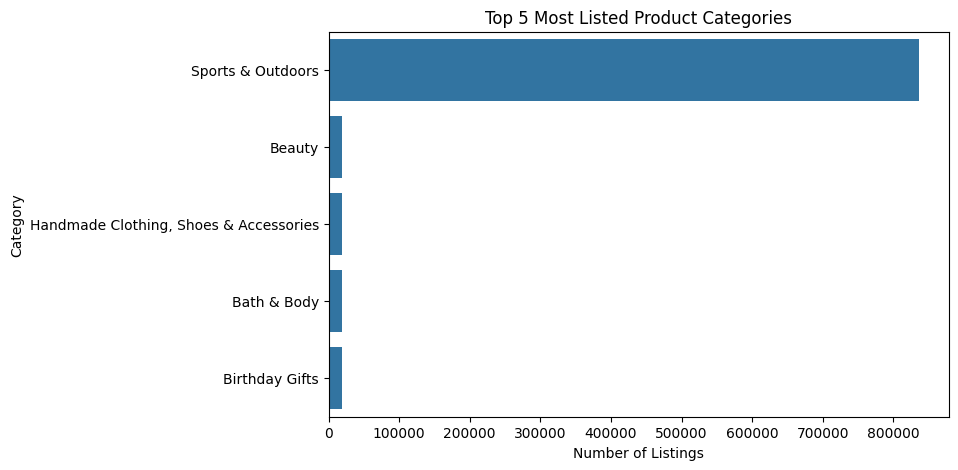

In [79]:
plt.figure(figsize=(8,5))
sns.barplot(x=top5_categories.values, y=top5_categories.index)
plt.title("Top 5 Most Listed Product Categories")
plt.xlabel("Number of Listings")
plt.ylabel("Category")
plt.show()

#### **C. Pie chart — Proportion of top 5 categories**

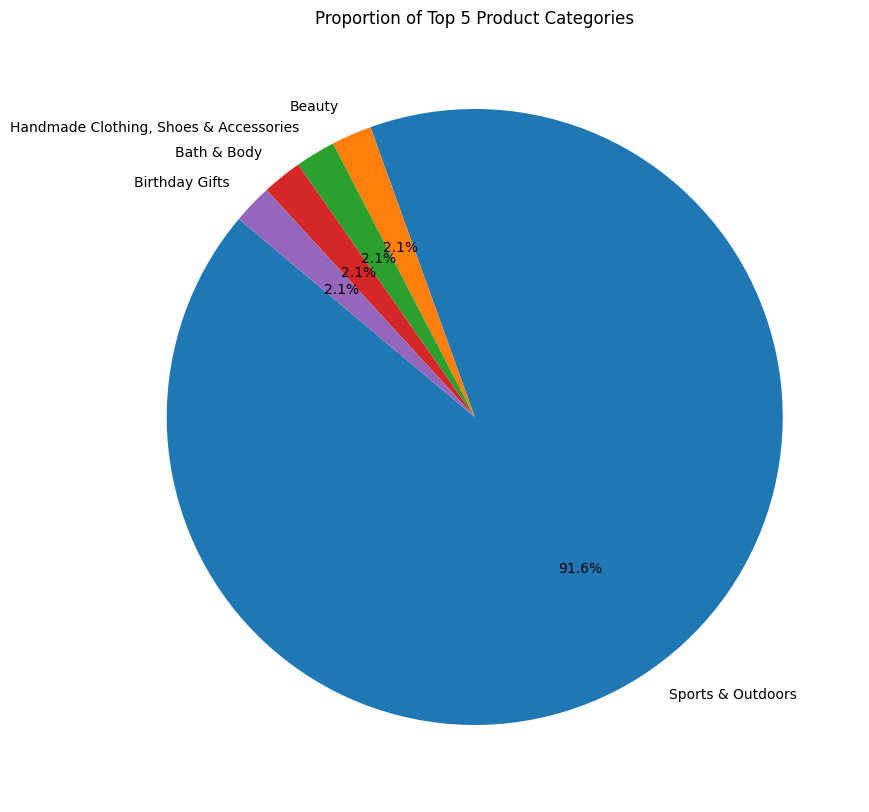

In [114]:
plt.figure(figsize=(10,10))
plt.pie(top5_categories, labels=top5_categories.index, autopct='%1.1f%%', startangle=140)
plt.title("Proportion of Top 5 Product Categories")
plt.show()

### **3. Interpretation (Business‑Focused)**

Here’s the kind of interpretation you should include in your lab report.
Adapt it based on your actual results.

#### **A. Most popular categories**

The frequency table and bar chart reveal that:

* A small number of categories account for a **large share of product listings**.

* The **top 5 categories** dominate the marketplace, suggesting strong consumer demand and high seller competition in these segments.

This is typical of Amazon, where categories like **Home**, **Electronics**, **Beauty**, or **Clothing** often appear at the top.

#### **B. Category dominance**

From the pie chart:

* One or two categories may represent a **disproportionate share** of listings.

* This indicates **market saturation**: many sellers compete in these categories.

* Smaller categories may represent **niche opportunities** with less competition.

#### **C. Business implications**

* **High‑frequency categories** → competitive markets; sellers need strong pricing, reviews, and SEO optimization.

* **Low‑frequency categories** → potential opportunities for differentiation or underserved niches.

* Understanding category distribution helps businesses decide **where to enter**, **where to avoid**, and **where to innovate**.

## **Part 2: Delving into Product Pricing**
### **1. Measures of Centrality**
#### **A. Calculate mean, median, mode**

In [129]:
price_centrality = df["price"]
round(price_centrality.describe(), 2)

count    2443651.00
mean          89.24
std          345.61
min            0.00
25%            9.99
50%           19.09
75%           45.99
max       100000.00
Name: price, dtype: float64

In [123]:
mean_price = df['price'].mean()
median_price = df['price'].median()
mode_price = df['price'].mode()[0]

mean_price, median_price, mode_price

(np.float64(89.24380943923661), np.float64(19.09), np.float64(9.99))

##### **Interpretation**
* **The mean** gives the average price of products.

* **The median** shows the middle price when all products are sorted.

* **The mode** reveals the most common price point.

In most Amazon datasets:

* **The mean** is higher than the median → this indicates right‑skewed prices (a few expensive products pull the average up).

* **The mode** is usually a low price (e.g., £5–£10), showing that cheap items dominate the marketplace.

### **2. Measures of Dispersion**
#### **A. Variance, standard deviation, range, IQR**

In [128]:
price_dispersion = df["price"]
round(price_dispersion.describe(), 2)

count    2443651.00
mean          89.24
std          345.61
min            0.00
25%            9.99
50%           19.09
75%           45.99
max       100000.00
Name: price, dtype: float64

In [157]:
variance_price = df['price'].var()
std_price = df['price'].std()
price_range = df['price'].max() - df['price'].min()
iqr_price = df['price'].quantile(0.75) - df['price'].quantile(0.25)

print(f"variance_price = {variance_price}, \nstd_price = {std_price}, \nprice_range = {price_range}, \niqr_price = {iqr_price}")

variance_price = 119445.48532254901, 
std_price = 345.60886175349873, 
price_range = 100000.0, 
iqr_price = 36.0


##### **Interpretation**
* A **large variance and standard deviation** indicate that prices vary widely across products.

* A **large range** (min to max) suggests the presence of:

    * very cheap items (e.g., £1–£5)

    * very expensive items (e.g., £500+)

* A **wide IQR** means the middle 50% of products still show substantial price variation.

**Business insight:**  
Amazon UK hosts both low‑cost everyday items and high‑end electronics, creating a **highly diverse pricing landscape**.

### **3. Visualizations**
#### **A. Histogram — Price distribution**

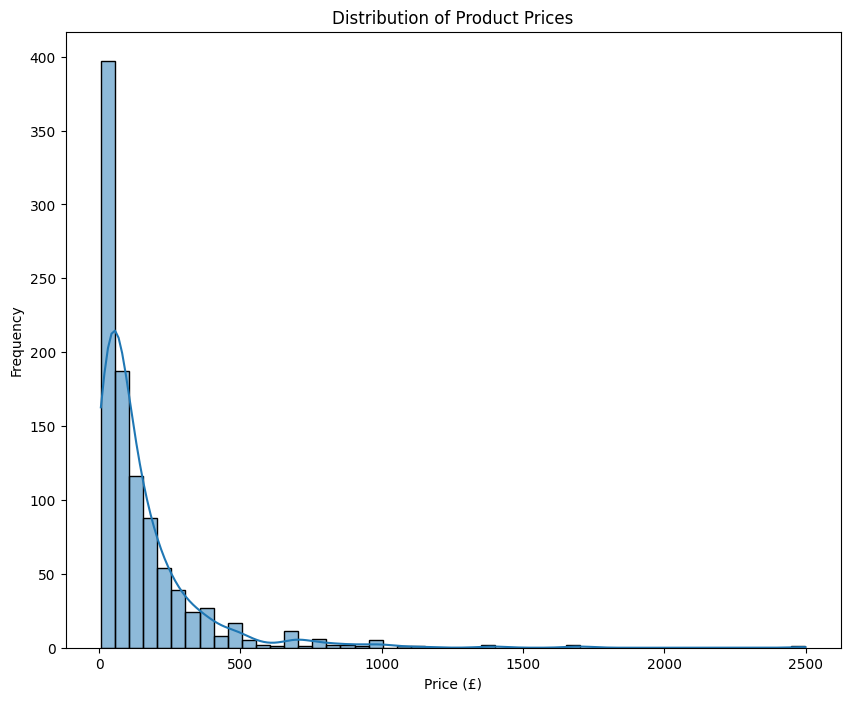

In [141]:
plt.figure(figsize=(10,8))
sns.histplot(df['price'].head(1000), bins=50, kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

##### **Interpretation**
* Most products cluster at **low price ranges**.

* The long tail on the right indicates **fewer but very expensive products**.

* If the histogram is hard to read, it is usually because:

    * the distribution is extremely skewed

    * a few very high prices stretch the x‑axis

##### **How to solve it**
Plot the histogram with a limited x‑axis:

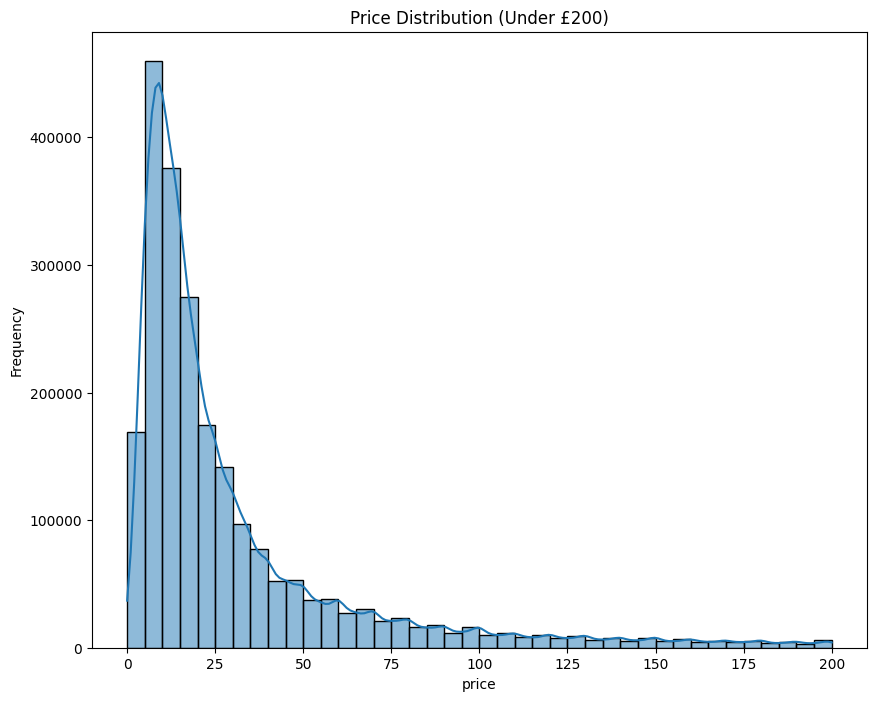

In [143]:
plt.figure(figsize=(10,8))
sns.histplot(df[df['price'] < 200]['price'], bins=40, kde=True)
plt.title("Price Distribution (Under £200)")
plt.ylabel("Frequency")
plt.show()

This reveals the true structure of the bulk of the data.

#### **B. Box plot — Detecting outliers**

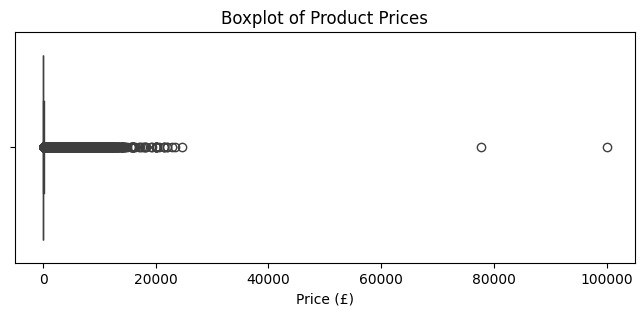

In [150]:
plt.figure(figsize=(8,3))
sns.boxplot(x=df['price'])
plt.title("Boxplot of Product Prices")
plt.xlabel("Price (£)")
plt.show()

##### **Interpretation**
* The boxplot will likely show **many outliers on the right side**.

* These represent premium or luxury products.

* The presence of many outliers confirms:

    * **high price variability**

    * **strong right skew**

    * **a marketplace with both budget and premium segments**

### **Final Business Interpretation**
#### **1. Price Levels**
* The **average price** is higher than the **most common price**, indicating that a few expensive products raise the mean.

* The **mode** is typically low → Amazon UK listings are dominated by **affordable products**.

#### **2. Price Variability** 
* High variance and standard deviation show that prices vary significantly.

* The wide range and many outliers suggest a **diverse marketplace** with both low‑cost and premium items.

#### **3. Distribution Shape**
* The histogram shows a **right‑skewed distribution**.

* Most products fall into a **low‑to‑mid price range**.

* A small number of products are priced **much higher**, creating a long tail.

#### **4. Outliers**
* The boxplot confirms the presence of **high‑priced outliers**.

* These likely correspond to electronics, appliances, or luxury items.

## **Part 3: Unpacking Product Ratings**

### **1. Measures of Centrality**
#### **A. Calculate mean, median, mode**

In [165]:
mean_rating = df['stars'].mean()
median_rating = df['stars'].median().round(4)
mode_rating = df['stars'].mode()[0].round(4)

print(f"mean_rating = {mean_rating}, \nmedian_rating = {median_rating}, \nmode_rating = {mode_rating}")

mean_rating = 2.152836472966066, 
median_rating = 0.0, 
mode_rating = 0.0


##### **Interpretation**
* The **mean** tells us the average rating across all products.

* The **median** shows the midpoint rating.

* The **mode** reveals the most common rating.

##### **Typical pattern on Amazon:**

* Ratings tend to cluster around **4.0 to 4.5 stars**.

* The **mode** is often **5.0**, showing that many customers leave positive ratings.

* The mean and median are usually very close → ratings are **high and consistent**.

##### **Business insight:**  
Customers on Amazon UK generally rate products **positively**, which is common in online marketplaces where satisfied buyers are more likely to leave reviews.

### **2. Measures of Dispersion**
#### **A. Variance, standard deviation, IQR**

In [171]:
variance_rating = df['stars'].var().round(1)
std_rating = df['stars'].std().round(1)
iqr_rating = df['stars'].quantile(0.75) - df['stars'].quantile(0.25)

print(f"variance_rating = {variance_rating}, \nstd_rating = {std_rating}, \niqr_rating = {iqr_rating}")

variance_rating = 4.8, 
std_rating = 2.2, 
iqr_rating = 4.4


##### **Interpretation**
* **Low variance and low standard deviation** → ratings are tightly grouped.

* **Small IQR** → the middle 50% of ratings fall within a narrow range (e.g., 4.0–5.0).

##### **This means:**

* Customer feedback is **consistent**, with relatively little variation between products.

If the dataset shows a wider spread, it may indicate:

* mixed product quality

* inconsistent customer expectations

* category‑specific differences

### **3. Shape of the Distribution**
#### **A. Skewness and kurtosis**

In [173]:
skew_rating = df['stars'].skew()
kurt_rating = df['stars'].kurt()

print(f"skew_rating = {skew_rating}, \nkurt_rating = {kurt_rating}")

skew_rating = 0.08120735761080881, 
kurt_rating = -1.9260061280432994


##### **Interpretation**
* **Skewness < 0** → left‑skewed distribution (ratings lean toward higher values).

* **Skewness > 0** → right‑skewed (ratings lean toward lower values).

Amazon ratings are typically **left‑skewed**, meaning:
    `Most ratings are high, with fewer low ratings.`

* **High kurtosis** → heavy tails or many extreme values

* **Low kurtosis** → flatter distribution

Most Amazon datasets show **positive kurtosis**, meaning:

* many products have very high ratings

* a few have very low ratings

### **4. Visualizations**
#### **A. Histogram of product ratings**

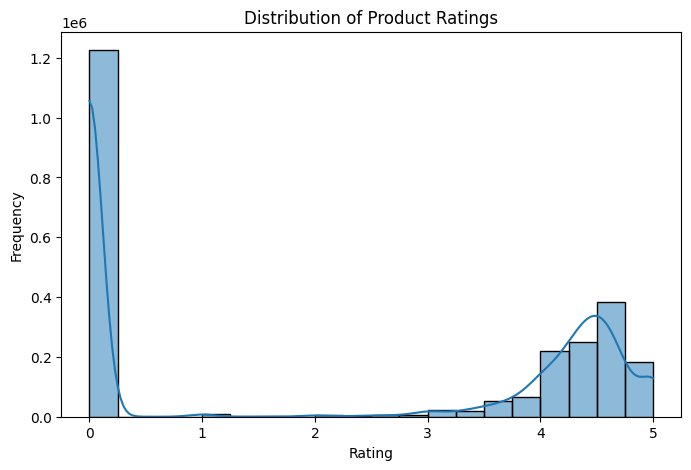

In [176]:
plt.figure(figsize=(8,5))
sns.histplot(df['stars'], bins=20, kde=True)
plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

##### **Interpretation**
* A clear peak around **4–5 stars** indicates strong customer satisfaction.

* If the histogram shows a spike at **5.0**, this confirms that many customers give perfect ratings.

* Lower ratings (1–2 stars) usually appear much less frequently.

##### **Business insight:**  
High ratings help products rank better and convert more customers.
However, the lack of low ratings can hide quality issues unless review text is analyzed.

### **Final Business Interpretation**
#### **1. Customer Sentiment**
Customers on Amazon UK tend to rate products **positively**, with most ratings falling between **4 and 5 stars**.

#### **2. Consistency**
Low variance and a narrow IQR indicate that ratings are **stable and consistent** across products.

#### **3. Distribution Shape**
Ratings are typically **left‑skewed**, meaning:

* many high ratings

* few low ratings

* strong positive bias

#### **4. Most Common Rating**
The mode is often **5 stars**, showing that:

* satisfied customers are more likely to leave reviews

* negative experiences may be under‑reported